## Check for gaps (?)

Test the following things in **processing** :
1. Did we extract strides in every mode (treadmill, levelground, ramp, stair) for all ppl? Flag cases with not enough strides.
2. Does treadmill and ramp have strides across multiple speeds and ramp angles respectively?
3. Are all electrodes present throughout trials for all subjects? (we actually need to check this in raw data)? Are any channels dead/flat with near 0 variance? Flag them if yes and also NaN cases.

Test **EMG Quality**
1. Does anyone have stride that's way off wrt. their own avg stride profile? We will have per subject per-subject mean/std reference.
2. What's the [min,max] of each muscle, each trial, for each person? 


### Imports

In [1]:
import os
os.environ["LEAPS_EMG_H5"] = "/home/nadinebadie/lalitha/datasets/emg_activations_v2.h5"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from leaps.data.metadata import LEAPS_H5_PATH
from leaps.data.stride_dataset import load_strides
from leaps.envs.emg_mapping import EMG_CHANNELS

_, metadata = load_strides(LEAPS_H5_PATH, with_metadata=True)
subjects, modes = metadata["subjects"], metadata["modes"]

### Strides
1. Did we get enough strides per person in every mode? YES
2. Do treadmill and ramp trials have strides extracted for each speed and angle resp.? YES
3. No concerning/missing values? ALL GOOD
4. Are there strides that are way off a person's own mean/std profile? -Not important atm

Note: The last 4 treadmill speeds (1.9-2.5) is only completed by AB06 and AB07

In [3]:
stride_counts = pd.crosstab(subjects, modes)
stride_counts

col_0,levelground,ramp,stair,treadmill
row_0,,,,
AB06,303,468,252,961
AB07,325,534,258,1036
AB08,364,431,210,811
AB09,385,506,246,802
AB10,322,431,269,851
AB11,330,505,264,841
AB12,342,472,258,808
AB13,290,482,234,859
AB14,312,461,240,903


In [4]:
#treadmill: check strides for all 6 speeds
conditions= metadata["conditions"]
treadmill_mask= modes == "treadmill" #boolean 1 when treadmill

treadmill_speeds = pd.crosstab(subjects[treadmill_mask], conditions[treadmill_mask]) #row i in these 2 arrays refers to the same stride
treadmill_speeds

col_0,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,...,1.60,1.65,1.70,1.75,1.80,1.85,1.90,1.95,2.00,2.05
row_0,,,,,,,,,,,,,,,,,,,,,
AB06,20,20,22,23,23,24,24,25,26,27,...,33,32,36,37,38,37,37,37,37,37
AB07,20,21,21,45,23,24,24,23,24,24,...,32,32,35,35,35,71,37,37,37,38
AB08,21,21,21,21,22,22,23,26,26,26,...,36,36,36,37,37,38,0,0,0,0
AB09,18,19,19,20,21,21,23,23,25,24,...,37,37,36,37,37,38,0,0,0,0
AB10,22,23,23,24,26,27,26,26,26,26,...,35,36,37,38,38,39,0,0,0,0
AB11,22,22,21,22,23,25,26,25,26,27,...,35,36,39,39,40,40,0,0,0,0
AB12,20,21,21,21,22,23,24,25,25,27,...,34,35,35,36,37,39,0,0,0,0
AB13,23,23,23,24,24,26,25,27,28,28,...,38,38,37,37,38,39,0,0,0,0
AB14,20,19,22,25,27,27,28,28,28,30,...,39,39,39,40,40,42,0,0,0,0


In [5]:
# CHECK FOR UNIQUE SPEEDS AND ANGLES
# for subject in treadmill_speeds.index:
#       row = treadmill_speeds.loc[subject]          #this person's row 
#       speeds_present = set(row[row > 0].index)      
#       print(subject, speeds_present)

#ramp: check strides for alll 6 speeds
ramp_mask= modes == "ramp" #boolean 1 when ramp
ramp_angles= pd.crosstab(subjects[ramp_mask], conditions[ramp_mask]) #6 angles
ramp_angles


col_0,11,12.4,18,5.2,7.8,9.2
row_0,,,,,,
AB06,76,80,90,70,76,76
AB07,91,86,106,102,79,70
AB08,70,71,80,70,70,70
AB09,80,80,98,88,80,80
AB10,70,75,76,70,70,70
AB11,97,88,88,70,69,93
AB12,76,89,80,73,76,78
AB13,70,70,90,78,104,70
AB14,70,94,87,70,70,70


In [6]:
strides, metadata = load_strides(LEAPS_H5_PATH, with_metadata=True) #shape (n,101,11)
subjects, modes, conditions = metadata["subjects"], metadata["modes"], metadata["conditions"]
np.isnan(strides).any()

False

In [7]:
for subject in np.unique(subjects):
    subject_strides= strides[subjects== subject] #(n,101,11)
    profile= subject_strides.mean(axis=0) #their own avg stride shape (101,11)
    deviation= ((subject_strides- profile)**2).mean(axis=(1,2)) #shape (n,)

    #we want to flag those strides that deviate more than 3.std of avg deviation of the resp. person
    threshold= deviation.mean() + 3*deviation.std()
    outliers= (deviation>threshold).sum() #count no.of outliers
    print(subject, outliers, "/", len(deviation))

AB06 39 / 1984
AB07 41 / 2153
AB08 44 / 1816
AB09 52 / 1939
AB10 33 / 1873
AB11 31 / 1940
AB12 43 / 1880
AB13 28 / 1865
AB14 41 / 1916
AB15 42 / 1819
AB16 38 / 1963
AB17 42 / 1767
AB18 38 / 1864
AB19 43 / 1893
AB20 46 / 1887
AB21 46 / 1917
AB23 30 / 1855
AB24 4 / 1799
AB25 59 / 2088
AB27 49 / 1879
AB28 46 / 2053
AB30 46 / 1802


/home/nadinebadie/anaconda3/envs/lalitha/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nadinebadie/anaconda3/envs/lalitha/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


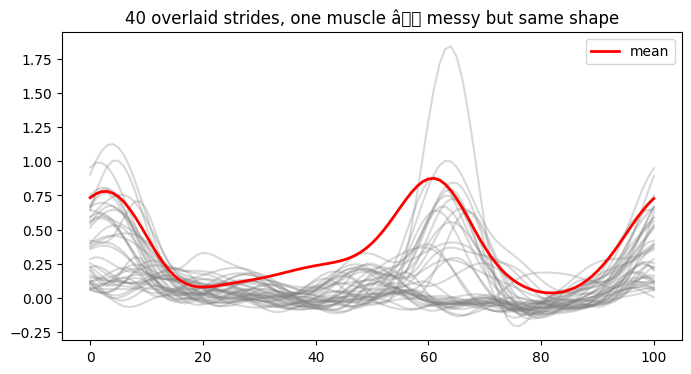

In [8]:
rf = EMG_CHANNELS.index("rectusfemoris")
sub = strides[(subjects == "AB16") & (modes == "treadmill")]
plt.figure(figsize=(8, 4))
for i in range(min(40, len(sub))):
    plt.plot(sub[i, :, rf], color="gray", alpha=0.3)
plt.plot(sub[:, :, rf].mean(axis=0), color="red", linewidth=2, label="mean")
plt.legend()
plt.title("40 overlaid strides, one muscle â messy but same shape")
plt.show()

### EMG Tests
1. Do all trials have electrodes present throughout? -NOT DOING RN BC WE NEED TO LOOK AT RAW
2. Any flat/dead channels or near 0 variance trials?- NO
3. Min, max values on average for each muscle in each mode for our loss function- 
4. Get the distribution of their amplitudes min-max per mode. Would tell us how to design the loss.

In [9]:
rows=[]
for subject in np.unique(subjects):
    subject_strides= strides[subjects== subject] #(n_ofthisperson, 101,11)
    channel_variance= subject_strides.reshape(-1,11).var(axis=0) #collapsing strides and timepoints into 1 axis because we want to compare 11 emgs as separate for comparing 1 var per channel
    rows.append(channel_variance)
    # print(subject, channel_variance)

#get stats from channel_variance table
channel_variances = pd.DataFrame(rows, index=np.unique(subjects), columns=EMG_CHANNELS)
col_mean = channel_variances.mean(axis=0)
col_std = channel_variances.std(axis=0)
z_scores = (channel_variances - col_mean) / col_std
flagged = z_scores < -2
flagged[flagged.any(axis=1)]

,gastrocmed,tibialisanterior,soleus,vastusmedialis,vastuslateralis,rectusfemoris,bicepsfemoris,semitendinosus,gracilis,gluteusmedius,rightexternaloblique


In [10]:
min_row=[]
max_row=[]
for subject in np.unique(subjects):
    subject_strides= strides[subjects== subject].reshape(-1,11) #(nx101, 11)
    min_row.append(subject_strides.min(axis=0))
    max_row.append(subject_strides.max(axis=0))

channel_min = pd.DataFrame(min_row, index=np.unique(subjects), columns=EMG_CHANNELS)
channel_max = pd.DataFrame(max_row, index=np.unique(subjects), columns=EMG_CHANNELS)

# channel_min
# channel_max

worst value: 66.7x  subject=AB18  mode=stair  muscle=rectusfemoris  at 39% of gait cycle


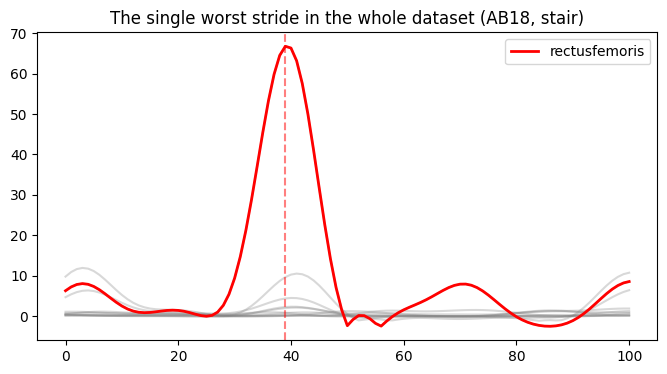

In [11]:
flat_idx = np.unravel_index(np.argmax(strides), strides.shape)
stride_i, t_i, ch_i = flat_idx
print(f"worst value: {strides[flat_idx]:.1f}x  subject={subjects[stride_i]}  mode={modes[stride_i]}  "
      f"muscle={EMG_CHANNELS[ch_i]}  at {t_i}% of gait cycle")

plt.figure(figsize=(8, 4))
for c in range(11):
    plt.plot(strides[stride_i, :, c], color="gray", alpha=0.3)
plt.plot(strides[stride_i, :, ch_i], color="red", linewidth=2, label=EMG_CHANNELS[ch_i])
plt.axvline(t_i, color="red", linestyle="--", alpha=0.5)
plt.legend()
plt.title(f"The single worst stride in the whole dataset ({subjects[stride_i]}, {modes[stride_i]})")
plt.show()

In [12]:
# spike = strides[stride_i, :, ch_i]
# print("frames above 10x:", (spike > 10).sum(), "/ 101")
# print("frames above 20x:", (spike > 20).sum(), "/ 101")
# plt.plot(spike, marker="o")
# plt.axhline(10, color="gray", linestyle=":")
# plt.show()

# print(strides[stride_i, t_i, :])


ab18_stair = strides[(subjects == "AB18") & (modes == "stair")]
rf = EMG_CHANNELS.index("rectusfemoris")
peak_per_stride = ab18_stair[:, :, rf].max(axis=1)
print(f"{(peak_per_stride > 10).sum()} / {len(peak_per_stride)} of AB18's stair strides exceed 10x in rectusfemoris")
print("peak values:", np.sort(peak_per_stride)[-10:])

194 / 270 of AB18's stair strides exceed 10x in rectusfemoris
peak values: [43.47378736 43.6034063  45.28072485 46.05064261 46.10754981 46.50859659
 46.63596323 55.09449672 64.52992613 66.73451191]


### Item 4: distribution per mode + where in the gait cycle it overshoots

Never actually did this one. Per-mode/per-muscle exceedance rate first, then phase-resolved (does overshoot cluster somewhere in the cycle, or is it spread out) -- feeds directly into whether the loss cap below should be phase-conditioned instead of a flat per-muscle number.

In [13]:
exceed = strides > 1
rows = []
for mode in np.unique(modes):
    mask = modes == mode
    rows.append(100 * exceed[mask].mean(axis=(0, 1)))
mode_exceed = pd.DataFrame(rows, index=np.unique(modes), columns=EMG_CHANNELS)
mode_exceed.round(1)

,gastrocmed,tibialisanterior,soleus,vastusmedialis,vastuslateralis,rectusfemoris,bicepsfemoris,semitendinosus,gracilis,gluteusmedius,rightexternaloblique
levelground,4.0,6.4,4.3,3.1,3.4,4.9,8.9,6.2,10.2,2.6,13.6
ramp,6.7,8.1,7.3,19.4,17.0,18.5,12.4,10.2,13.4,5.6,15.7
stair,5.5,8.8,5.6,21.2,17.8,28.7,10.3,8.0,10.1,7.5,6.0
treadmill,5.1,8.0,5.6,6.1,5.5,8.0,7.9,6.6,7.4,4.0,10.6


In [14]:
# per muscle: overall rate + which phase % it peaks at
phase_rate = exceed.mean(axis=0) * 100  # (101, 11), % of strides >1 at each phase point
peak_phase = phase_rate.argmax(axis=0)
peak_rate = phase_rate.max(axis=0)

summary = pd.DataFrame({
    "pct_samples_over_1": 100 * exceed.mean(axis=(0, 1)),
    "pct_strides_ever_over_1": 100 * exceed.any(axis=1).mean(axis=0),
    "peak_phase_pct": peak_phase,
    "peak_rate_pct": peak_rate,
}, index=EMG_CHANNELS)
summary.sort_values("pct_samples_over_1", ascending=False).round(1)

,pct_samples_over_1,pct_strides_ever_over_1,peak_phase_pct,peak_rate_pct
rectusfemoris,12.8,66.2,4,48.8
rightexternaloblique,11.8,64.5,88,32.0
vastusmedialis,10.9,64.8,3,51.2
gracilis,9.7,57.4,51,23.2
vastuslateralis,9.6,64.3,3,48.1
bicepsfemoris,9.5,58.4,95,26.6
tibialisanterior,7.9,58.0,98,27.1
semitendinosus,7.6,56.3,90,23.8
soleus,5.8,48.8,40,37.3
gastrocmed,5.4,54.3,37,34.8


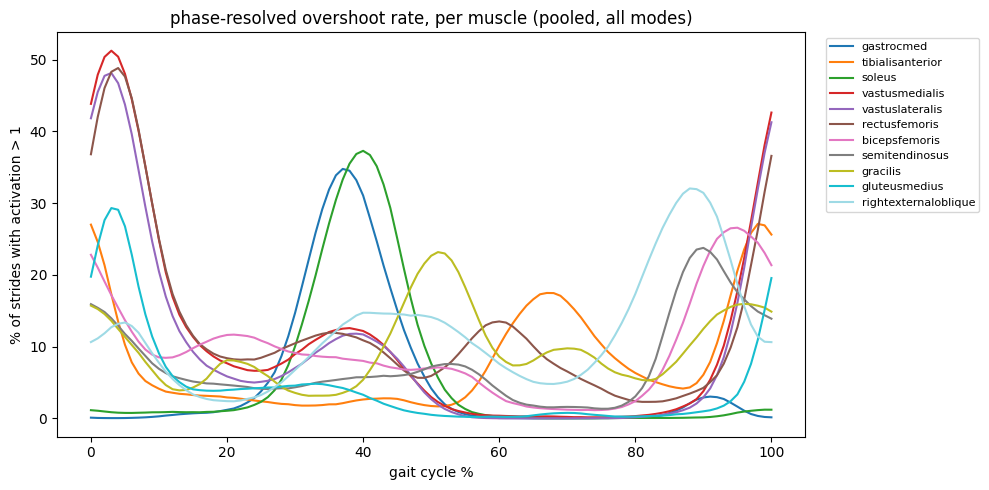

In [15]:
plt.figure(figsize=(10, 5))
colors = plt.cm.tab20(np.linspace(0, 1, 11))
for c in range(11):
    plt.plot(phase_rate[:, c], label=EMG_CHANNELS[c], color=colors[c])
plt.xlabel("gait cycle %")
plt.ylabel("% of strides with activation > 1")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.title("phase-resolved overshoot rate, per muscle (pooled, all modes)")
plt.tight_layout()
plt.show()

Clusters into three physiologically sensible groups, not spread evenly across the cycle:
- **~0-5% (heel strike / loading response):** vastusmedialis, vastuslateralis, rectusfemoris, gluteusmedius -- eccentric quad/hip control absorbing impact
- **~30-45% (mid-stance / push-off):** gastrocmed, soleus -- calf propulsion
- **~85-98% (terminal swing):** tibialisanterior, bicepsfemoris, semitendinosus, rightexternaloblique -- hamstrings decelerating the swinging shank, tib. ant. pre-positioning the foot

So the >1 mass isn't noise smeared across the whole stride -- it's concentrated exactly where each muscle's real peak sits. Argues for phase-conditioning the loss cap by these three windows rather than one flat per-muscle number.

### Designing loss fn.

treat samples where the target sits at the ceiling as one-sided. 
only penalize the model if it predicts below the target; don't penalize predicting above it (but whats the cap?)

  `loss_i = (pred_i - target_i)^2                         if target_i < cap    
         = max(0, target_i - pred_i)^2                    if target_i >= cap AND pred_i <= margin
         = (pred_i - margin)^2                            if target_i >= cap AND pred_i > margin`  

- frac table tells when this matters: for AB16 specifically, rightexternaloblique (~11%) and rectusfemoris (~10%) are the two muscles where this special-casing will actually move the needle; the others are low enough (<8%) that plain MSE is probably fine there.

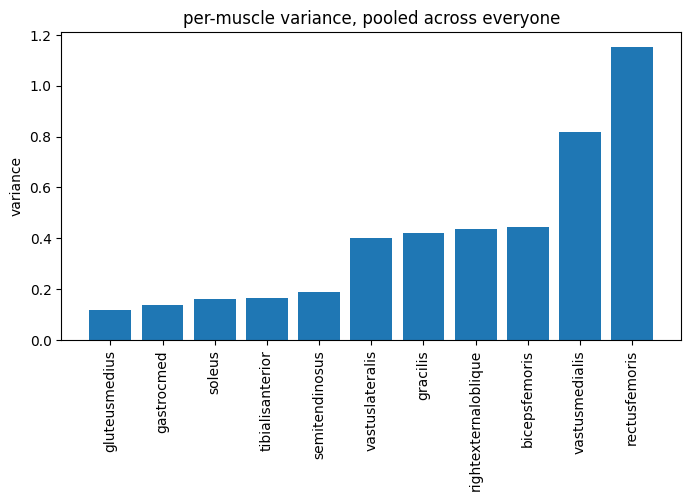

gluteusmedius          var=0.1177  (1.0x the smallest)
gastrocmed             var=0.1362  (1.2x the smallest)
soleus                 var=0.1607  (1.4x the smallest)
tibialisanterior       var=0.1648  (1.4x the smallest)
semitendinosus         var=0.1897  (1.6x the smallest)
vastuslateralis        var=0.4004  (3.4x the smallest)
gracilis               var=0.4219  (3.6x the smallest)
rightexternaloblique   var=0.4383  (3.7x the smallest)
bicepsfemoris          var=0.4439  (3.8x the smallest)
vastusmedialis         var=0.8174  (6.9x the smallest)
rectusfemoris          var=1.1532  (9.8x the smallest)


In [16]:
X = strides.reshape(-1, 11)
var = X.var(axis=0)
order = np.argsort(var)

plt.figure(figsize=(8, 4))
plt.bar(range(11), var[order])
plt.xticks(range(11), [EMG_CHANNELS[i] for i in order], rotation=90)
plt.ylabel("variance")
plt.title("per-muscle variance, pooled across everyone")
plt.show()

for i in order:
    print(f"{EMG_CHANNELS[i]:22s} var={var[i]:.4f}  ({var[i]/var[order[0]]:.1f}x the smallest)")